# Leaf Species Classification using Convolutional Neural Networks

**Author:** Vigneshwar Lokoji

### Problem Statement

Given a dataset of 12,000 labeled leaf images across 176 distinct species, the goal is to build a classification model that can accurately identify the species of a leaf from its image. This is a **fine-grained image classification** problem -- the differences between species can be subtle (vein patterns, edge serrations, leaf shape), making it significantly harder than general object classification.

### Approach

This notebook takes a structured, concept-by-concept approach to solving this problem:

1. **Data Exploration** -- Understanding the dataset structure, class distribution, and image properties
2. **Preprocessing Pipeline** -- Resizing, tensor conversion, normalization, and data augmentation
3. **CNN Fundamentals** -- Building understanding of convolutions, pooling, and fully connected layers from scratch
4. **Experiment 1: Custom CNN** -- Training a model built from scratch to establish a baseline
5. **Experiment 2: Transfer Learning** -- Leveraging a pretrained ResNet-50 with fine-tuning
6. **Experiment 3: Differential Learning Rate Fine-Tuning** -- Advanced fine-tuning strategy with layer-wise learning rates
7. **Visual Testing** -- Inspecting model predictions to understand behavior beyond accuracy numbers

## 1. Setup and Imports

Importing all required libraries upfront. Each serves a specific purpose:
- **os, pandas, PIL** -- File handling, data manipulation, and image loading
- **matplotlib** -- Visualization of images and training metrics
- **torchvision.transforms** -- Image preprocessing and augmentation pipeline
- **torch.nn** -- Neural network layers (Conv2d, Linear, BatchNorm, etc.)
- **torch.utils.data** -- Dataset and DataLoader classes for efficient batching
- **sklearn** -- Train/validation splitting with stratification

In [1]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from collections import Counter
import torch
from torchvision import transforms
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch.nn as nn

## 2. Data Loading

The dataset is stored in a Kaggle input directory. It contains:
- **train_midterm.csv** -- Maps 12,000 image filenames to their species labels
- **images/** -- Directory containing all leaf images (both labeled and unlabeled)

We define `base_dir` as a single reference point so all file paths are built from one location. If the path changes, we update one line instead of many.

In [2]:
base_dir = '/kaggle/input/competitions/midterm-exam-classification-leaves'
train_csv = os.path.join(base_dir, 'train_midterm.csv')

df = pd.read_csv(train_csv)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

Shape: (12000, 2)
Columns: ['image', 'label']
                  image                 label
0  images/img_00000.jpg  pseudolarix_amabilis
1  images/img_00001.jpg      cedrus_atlantica
2  images/img_00002.jpg         cedrus_libani
3  images/img_00003.jpg       quercus_montana
4  images/img_00004.jpg      catalpa_speciosa


### 2.1 Data Quality Check

Before any analysis, we check for **null values** (missing data) and **duplicates** (repeated entries). This should always be done immediately after loading -- everything downstream depends on clean data. Null labels would crash the training loop; duplicate images would inflate accuracy and cause overfitting.

In [3]:
# Nulls
print(df.isnull().sum())

# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate images: {df['image'].duplicated().sum()}")

image    0
label    0
dtype: int64
Duplicate rows: 0
Duplicate images: 0


### 2.2 Class Distribution Analysis

Understanding how many unique species exist and how images are distributed across them. This reveals **class imbalance** -- if some species have far more images than others, the model may become biased toward over-represented classes and struggle with rare ones.

In [4]:
print(df['label'].nunique())
print(df['label'].unique())


176
['pseudolarix_amabilis' 'cedrus_atlantica' 'cedrus_libani'
 'quercus_montana' 'catalpa_speciosa' 'betula_lenta' 'ilex_opaca'
 'salix_nigra' 'ulmus_americana' 'pinus_wallichiana' 'aesculus_glabra'
 'crataegus_phaenopyrum' 'platanus_occidentalis' 'magnolia_macrophylla'
 'cornus_florida' 'prunus_serotina' 'magnolia_grandiflora'
 'pinus_sylvestris' 'cedrus_deodara' 'pinus_strobus' 'carya_cordiformis'
 'salix_matsudana' 'chionanthus_retusus' 'quercus_nigra'
 'maclura_pomifera' 'salix_caroliniana' 'pinus_echinata' 'styrax_japonica'
 'gleditsia_triacanthos' 'quercus_virginiana' 'tsuga_canadensis'
 'quercus_marilandica' 'pinus_parviflora' 'pinus_rigida' 'ulmus_pumila'
 'acer_rubrum' 'picea_abies' 'cercis_canadensis' 'pinus_pungens'
 'quercus_macrocarpa' 'amelanchier_canadensis' 'quercus_shumardii'
 'pinus_densiflora' 'cornus_kousa' 'acer_griseum' 'abies_nordmanniana'
 'prunus_subhirtella' 'prunus_sargentii' 'platanus_acerifolia'
 'betula_nigra' 'stewartia_pseudocamellia' 'pinus_nigra' 'fra

### 2.3 Images Per Species

Examining the exact count per species. The most frequent species (`maclura_pomifera`) has 258 images while the rarest (`juniperus_virginiana`) has only 18 -- a 14:1 imbalance. This confirms we need data augmentation and stratified splitting to ensure all species are properly represented during training.

In [5]:
print(df['label'].value_counts())

label
maclura_pomifera        258
acer_rubrum             173
prunus_virginiana       162
prunus_sargentii        161
ulmus_rubra             158
                       ... 
ailanthus_altissima      29
crataegus_crus-galli     29
evodia_daniellii         28
ulmus_procera            26
juniperus_virginiana     18
Name: count, Length: 176, dtype: int64


### 2.4 Visualizing Sample Images

Looking at actual images before building any model. This helps verify that file paths are correct and gives an intuitive sense of the visual differences between species -- shape, color, vein patterns, edge types -- that the CNN will need to learn.

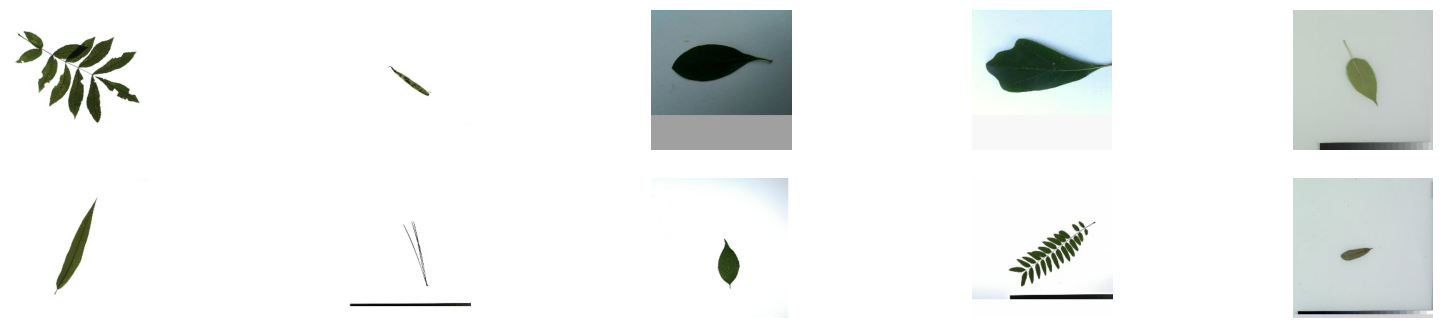

In [6]:
df['full_path'] = '/kaggle/input/competitions/midterm-exam-classification-leaves/images/images/' + df['image'].apply(os.path.basename)
fig, axes = plt.subplots(2, 5, figsize=(20, 4))
axes = axes.flatten() 
paths = df['full_path'][20:30]

for i, path in enumerate(paths):
    img = Image.open(path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()



## 3. Image Preprocessing

### 3.1 Image Size Check

Neural networks require all input images to have the **same dimensions**. Before deciding on a resize strategy, we check what sizes the images already are. If they vary, resizing is mandatory; if they're uniform, it's a safety net.

In [7]:
img = Image.open(df['full_path'][0])
print(f"Original size: {img.size}")

Original size: (224, 224)


### 3.2 Full Dataset Size Audit

Checking the size of every image in the dataset, not just one sample. All 12,000 images are 224x224 -- a uniform dataset. Resizing is still included in our pipeline as a best practice, since in real-world projects image sizes often vary.

In [8]:
sizes = []
for path in df['full_path']:
    img = Image.open(path)
    sizes.append(img.size)

size_counts = Counter(sizes)
print(f"Unique sizes found: {len(size_counts)}")
print(size_counts)

Unique sizes found: 1
Counter({(224, 224): 12000})


### 3.3 Resize Transform

Even though all images are already 224x224, we include `transforms.Resize((224, 224))` as a safety step. The size 224x224 is standard for most pretrained models (ResNet, VGG, EfficientNet) since they were trained on ImageNet at this resolution.

In [9]:
resize = transforms.Resize((224, 224))
resized_img = resize(img)

### 3.4 Visual Comparison: Original vs Resized

Side-by-side comparison showing the resize operation. In our case the images are identical since they're already 224x224, but this visualization confirms the transform is working correctly.

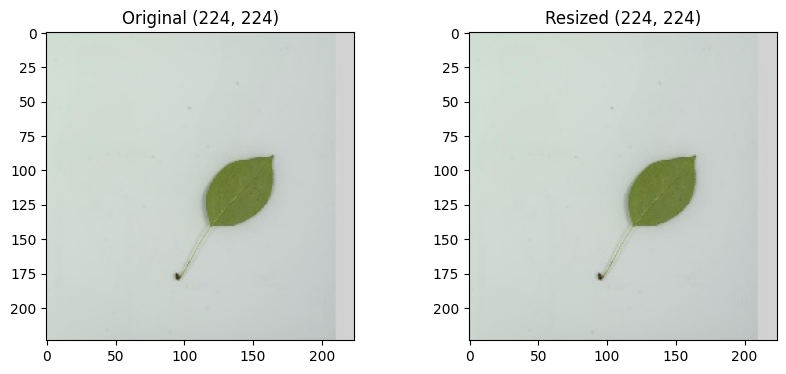

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title(f'Original {img.size}')
axes[1].imshow(resized_img)
axes[1].set_title(f'Resized {resized_img.size}')
plt.show()

### 3.5 Transform Pipeline (Compose)

`transforms.Compose` chains multiple preprocessing steps into a single pipeline. Each image passes through the steps in order: resize first, then convert to tensor. This pipeline is applied **on-the-fly** when images are loaded during training -- we don't preprocess and save all 12,000 images upfront, which saves disk space and allows easy modification.

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

### 3.6 Converting Images to Tensors

`ToTensor()` performs two operations:
1. Converts the PIL image into a PyTorch tensor (a multi-dimensional array)
2. Rescales pixel values from the original 0-255 range (8-bit) to 0-1

The resulting shape `[3, 224, 224]` means 3 color channels (Red, Green, Blue), each as a 224x224 grid of numbers. This is what the neural network actually "sees" -- not a picture, just numbers.

In [12]:
img = Image.open(df['full_path'][0])

# Step 1: Just ToTensor
to_tensor = transforms.ToTensor()
tensor_img = to_tensor(img)

print(f"Type: {type(tensor_img)}")
print(f"Shape: {tensor_img.shape}")
print(f"Min value: {tensor_img.min():.4f}")
print(f"Max value: {tensor_img.max():.4f}")

Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min value: 0.0000
Max value: 0.9804


### 3.7 Normalization

Normalization **centers and scales** the tensor values using the formula: `new_value = (old_value - mean) / std`

Values above the mean become positive, values below become negative. This is why the range shifts from [0, 1] to approximately [-2.1, 2.5].

The specific values `mean=[0.485, 0.456, 0.406]` and `std=[0.229, 0.224, 0.225]` are the statistics of the ImageNet dataset (1.2 million images). We use these because our pretrained models were trained with this normalization -- matching it ensures the model receives input in the same scale it learned on.

**Why normalize?** Without it, all values are between 0 and 1 (centered around 0.5), but the network's weights start near 0. This mismatch forces the network to spend early epochs just adjusting to the scale. Centering around 0 lets the network focus on learning patterns from the start.

Three views of the same image at different preprocessing stages. To our eyes they look similar, but the underlying numbers are very different. The neural network operates on the numbers, not the visual appearance. Note: `.permute(1, 2, 0)` rearranges the tensor from PyTorch format `[C, H, W]` to matplotlib format `[H, W, C]` for display.

In [13]:
# Without normalization
print(f"Before normalize -- Mean: {tensor_img.mean():.4f}, Std: {tensor_img.std():.4f}")

# Apply normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
normalized_img = normalize(tensor_img)

print(f"After normalize  -- Mean: {normalized_img.mean():.4f}, Std: {normalized_img.std():.4f}")
print(f"After normalize  -- Min: {normalized_img.min():.4f}, Max: {normalized_img.max():.4f}")

Before normalize -- Mean: 0.5867, Std: 0.2370
After normalize  -- Mean: 0.6146, Std: 1.1390
After normalize  -- Min: -2.1179, Max: 2.5529


### 3.8 Visual Comparison: Original vs Tensor vs Normalized

Three views of the same image at different preprocessing stages. To our eyes they look similar, but the underlying numbers are very different. The neural network operates on the numbers, not the visual appearance. Note: `.permute(1, 2, 0)` rearranges the tensor from PyTorch format `[C, H, W]` to matplotlib format `[H, W, C]` for display.

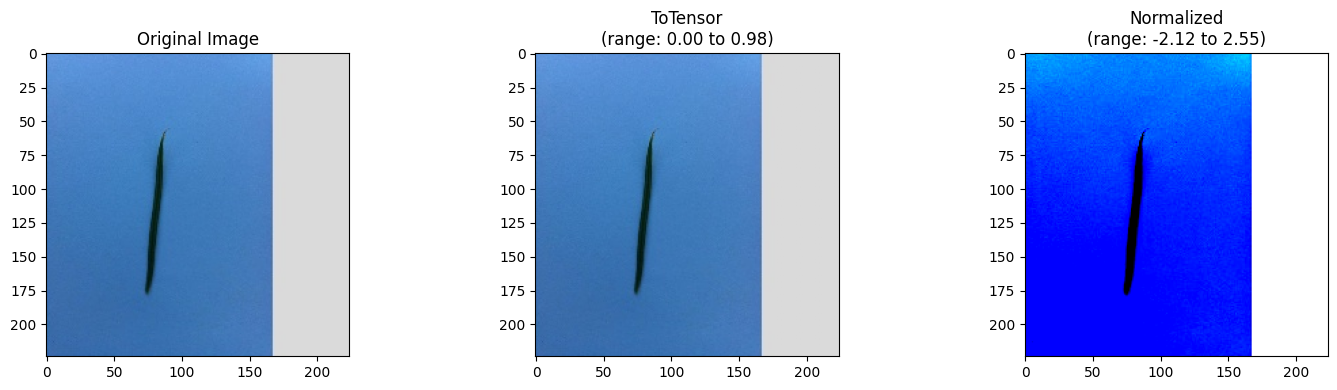

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original image
axes[0].imshow(img)
axes[0].set_title('Original Image')

# Tensor (0-1 range) -- need to rearrange from (3,224,224) to (224,224,3) for matplotlib
axes[1].imshow(tensor_img.permute(1, 2, 0))
axes[1].set_title(f'ToTensor\n(range: {tensor_img.min():.2f} to {tensor_img.max():.2f})')

# Normalized -- clip values to 0-1 for display purposes
display_norm = normalized_img.permute(1, 2, 0).clip(0, 1)
axes[2].imshow(display_norm)
axes[2].set_title(f'Normalized\n(range: {normalized_img.min():.2f} to {normalized_img.max():.2f})')

plt.tight_layout()
plt.show()

## 4. Data Augmentation

Data augmentation creates **random variations** of training images (flipped, rotated, color-shifted) so the model sees a different version each epoch. This is critical for two reasons:

1. **Expands the effective dataset** -- Some species have only 18 images. Augmentation gives the model a "new" view each time.
2. **Teaches invariance** -- A leaf is still the same species whether it's flipped, rotated 15 degrees, or photographed in different lighting.

**Important:** Only augment training data, never validation data. Validation must be consistent to give a reliable performance measurement.

Augmentations chosen for leaf classification:
- `RandomHorizontalFlip` -- Leaves can be photographed from either side
- `RandomRotation(30)` -- Leaves can be held at different angles
- `ColorJitter` -- Lighting conditions vary (sunny, cloudy, indoor)

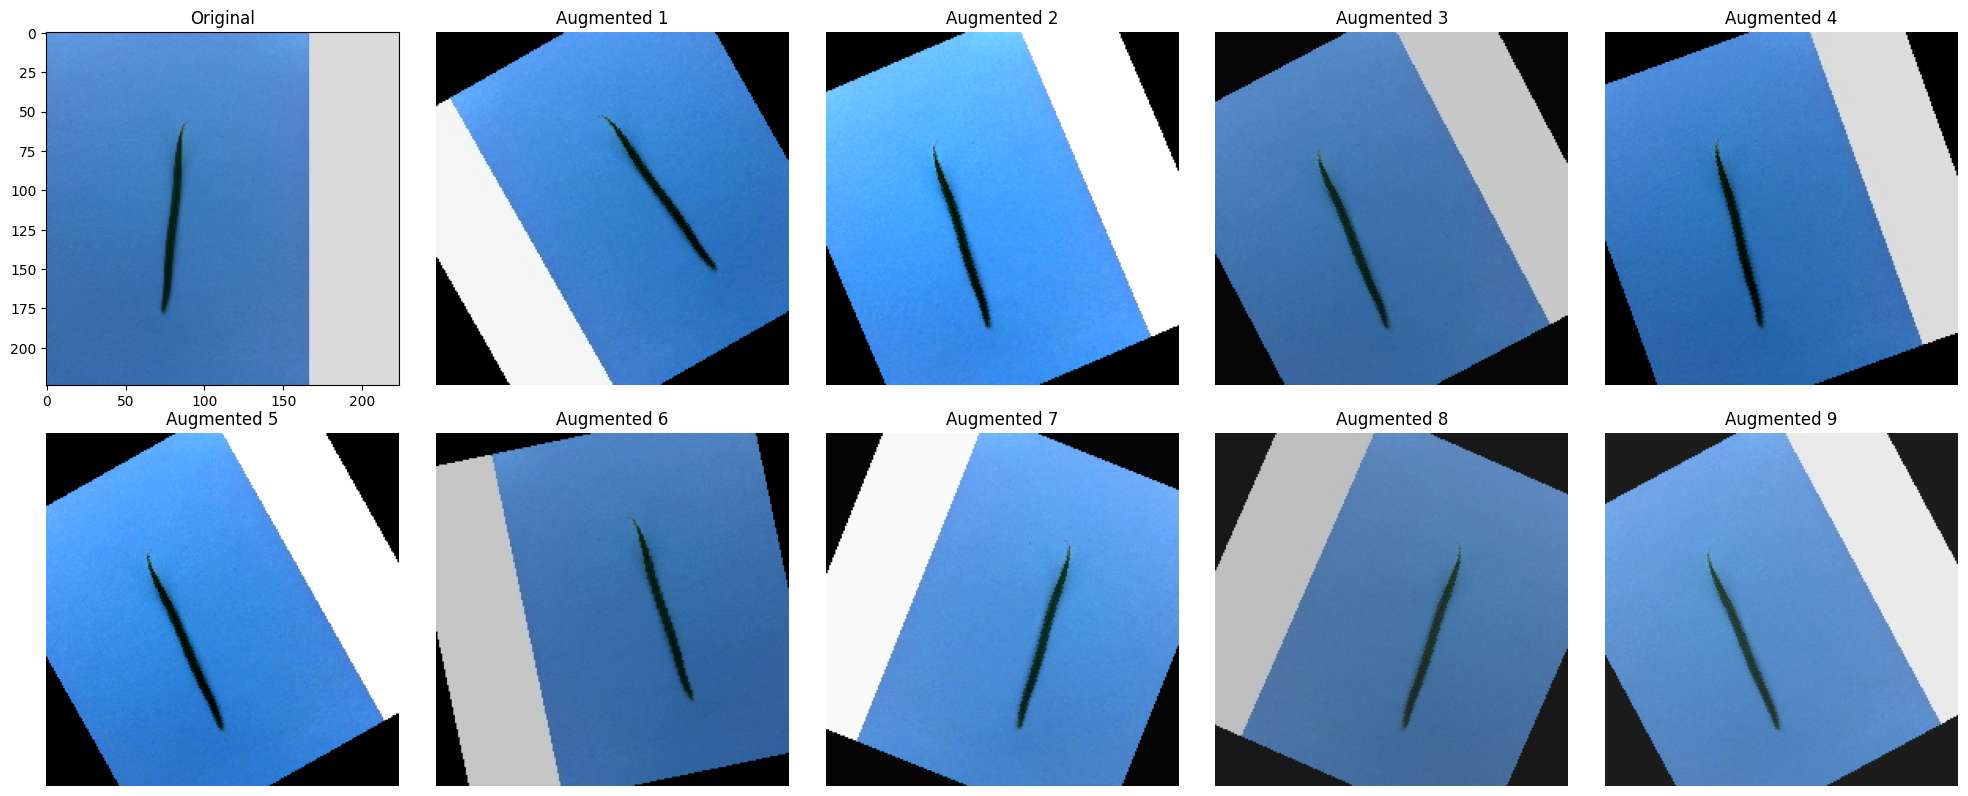

In [15]:
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])

img = Image.open(df['full_path'][0])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
axes[0].imshow(img)
axes[0].set_title('Original')

for i in range(1, 10):
    aug_img = augment(img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 4.1 Training and Validation Transform Pipelines

Two separate pipelines:

**Training transforms** -- includes augmentation + tensor conversion + normalization. The randomness means each epoch shows the model different variations of the same images. Order matters: augmentations operate on PIL images, so they come before `ToTensor()`.

**Validation transforms** -- only resize + tensor conversion + normalization. No augmentation, ensuring consistent and honest evaluation of model performance.

In [16]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 5. Custom Dataset Class

PyTorch's `Dataset` class defines **how to load and serve data**. It acts like a librarian -- you ask for item number `i`, and it knows where to find the image, how to open it, what label to assign, and what transforms to apply.

Three required components:
- `__init__` -- Stores references to the dataframe, image directory, transforms, and label mapping
- `__len__` -- Returns the total number of images (used by DataLoader to determine batch count)
- `__getitem__` -- Loads and returns one (image, label) pair when called with an index. This is invoked automatically during training; random augmentations ensure each call returns a slightly different version of the same image

`.convert('RGB')` ensures all images have exactly 3 channels, handling edge cases where images might be grayscale or have a transparency channel.

In [17]:
class LeafDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, class_to_idx=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = class_to_idx
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get filename and build full path
        img_name = os.path.basename(self.df.iloc[idx]['image'])
        img_path = os.path.join(self.img_dir, img_name)
        
        # Open image
        image = Image.open(img_path).convert('RGB')
        
        # Get label
        label = self.class_to_idx[self.df.iloc[idx]['label']]
        
        # Apply transforms if we have them
        if self.transform:
            image = self.transform(image)
        
        return image, label

### 5.1 Label Encoding

Neural networks require **numeric labels**, not strings like `"acer_rubrum"`. We create a mapping dictionary: each species name is assigned a unique integer (0-175). This mapping is sorted alphabetically to ensure consistency -- the same species always maps to the same number regardless of the order images appear in the dataset.

In [18]:
# Create mapping: species name → number
class_names = sorted(df['label'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f"Total classes: {len(class_to_idx)}")
print(f"Example: 'acer_rubrum' → {class_to_idx.get('acer_rubrum')}")

Total classes: 176
Example: 'acer_rubrum' → 10


### 5.2 Dataset Verification

Testing the dataset class by loading one image and confirming:
- The image tensor has the correct shape `[3, 224, 224]` (3 channels, 224x224 pixels)
- The label is an integer (not a string), confirming our class mapping works

In [19]:
img_dir = '/kaggle/input/competitions/midterm-exam-classification-leaves/images/images'

test_dataset = LeafDataset(df, img_dir, transform=val_transforms, class_to_idx=class_to_idx)

image, label = test_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Image shape: torch.Size([3, 224, 224])
Label: 132


### 5.3 Train/Validation Split with Stratification

Splitting the dataset: 80% for training (9,600 images), 20% for validation (2,400 images).

**`stratify=df['label']`** is critical here. Without it, a random split could put all 18 images of a rare species into the validation set, leaving zero examples for training. Stratification ensures the **same proportion** of each species appears in both sets. If a species has 100 images, roughly 80 go to training and 20 to validation.

`random_state=42` makes the split reproducible -- running this cell again produces the same split.

In [20]:
test_dataset = LeafDataset(df, img_dir, transform=val_transforms, class_to_idx=class_to_idx)
image, label = test_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label} (type: {type(label)})")

Image shape: torch.Size([3, 224, 224])
Label: 132 (type: <class 'int'>)


In [21]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")

Training images: 9600
Validation images: 2400


### 5.4 DataLoaders

DataLoaders wrap the datasets to handle **batching, shuffling, and efficient loading**:

- `batch_size=32` -- The model processes 32 images at a time. With 9,600 training images, that's 300 batches per epoch.
- `shuffle=True` (training) -- Images are presented in a different random order each epoch, preventing the model from memorizing sequences.
- `shuffle=False` (validation) -- Consistent ordering for reproducible evaluation.

The output shape `[32, 3, 224, 224]` confirms: 32 images per batch, each with 3 color channels at 224x224 resolution.

In [22]:
train_dataset = LeafDataset(train_df, img_dir, transform=train_transforms, class_to_idx=class_to_idx)
val_dataset = LeafDataset(val_df, img_dir, transform=val_transforms, class_to_idx=class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Test it
images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])


## 6. Understanding CNN Building Blocks

Before building a full model, we examine each component individually to understand what it does.

### 6.1 Convolution Layer

A `Conv2d` layer slides small filters (kernels) across the image to detect patterns. The input has 3 channels (RGB); the output has 16 channels -- each channel is a **feature map** that detects a different pattern (edges at various angles, color transitions, texture gradients). The spatial dimensions (224x224) remain the same because we use `padding=1`.

In [23]:
# A single convolution operation on our image
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

image = images[0].unsqueeze(0)  # take first image from our batch, add batch dimension
features = conv_layer(image)

print(f"Input shape: {image.shape}")
print(f"Output shape: {features.shape}")

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 16, 224, 224])


### 6.2 Visualizing Feature Maps

Each of the 16 feature maps highlights different aspects of the leaf image. Some detect edges, others respond to texture or color intensity. These filters are currently **random** (untrained) -- after training, they learn to detect meaningful patterns like leaf veins, serrated edges, and species-specific shapes.

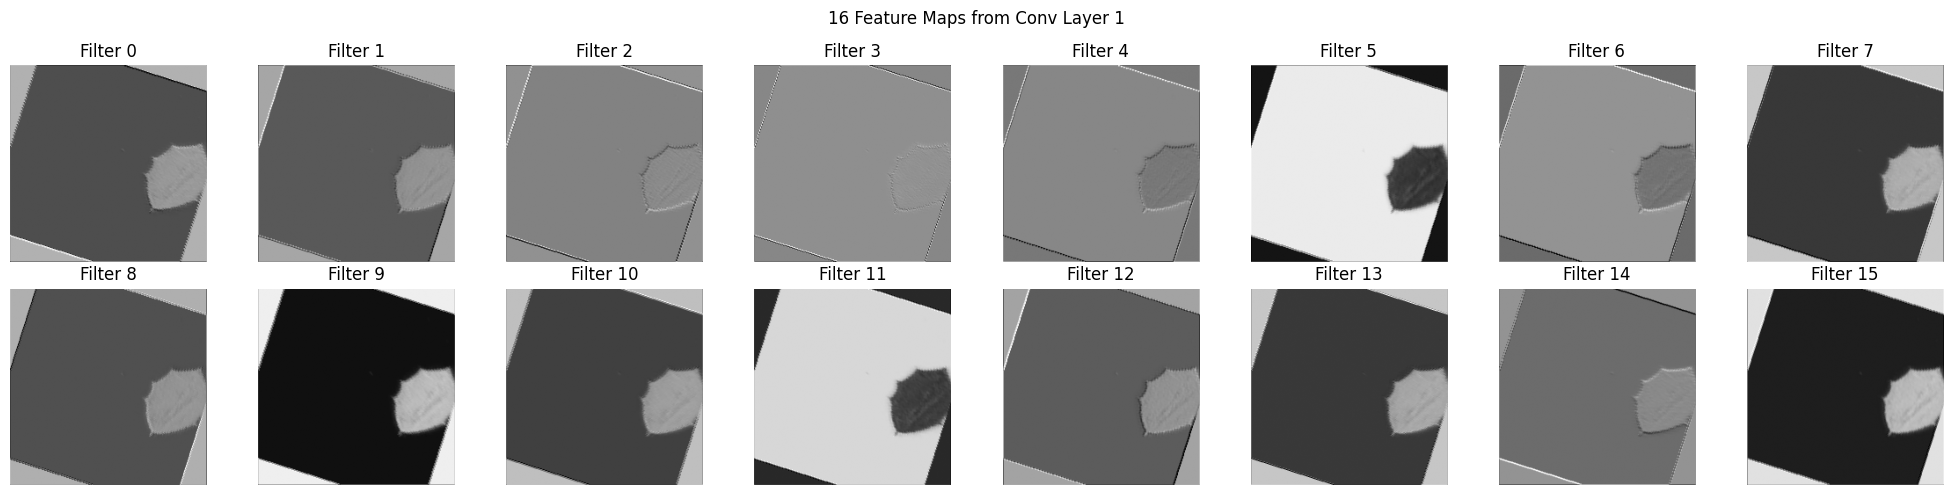

In [24]:
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.flatten()

for i in range(16):
    axes[i].imshow(features[0][i].detach().numpy(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Filter {i}')

plt.suptitle('16 Feature Maps from Conv Layer 1')
plt.tight_layout()
plt.show()

### 6.3 Max Pooling

`MaxPool2d(kernel_size=2, stride=2)` shrinks the spatial dimensions by half. It takes every 2x2 block of pixels and keeps only the **maximum value**, discarding the rest. This has two benefits:
1. Reduces computation (fewer pixels to process in subsequent layers)
2. Retains the strongest features while discarding spatial details -- the model learns "what" is present, not "where" exactly

In [25]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled = pool(features)

print(f"Before pooling: {features.shape}")
print(f"After pooling: {pooled.shape}")

Before pooling: torch.Size([1, 16, 224, 224])
After pooling: torch.Size([1, 16, 112, 112])


### 6.4 Stacking Multiple Layers

A CNN stacks Conv+Pool layers repeatedly. At each stage:
- **Channels increase** (3 → 16 → 32 → 64) -- detecting progressively more complex patterns
- **Spatial size decreases** (224 → 112 → 56 → 28) -- focusing on abstract features over exact positions

Layer 1 detects simple edges. Layer 2 combines edges into shapes. Layer 3 combines shapes into recognizable parts (leaf tips, vein patterns).

In [26]:
conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
pool = nn.MaxPool2d(2, 2)

x = images[0].unsqueeze(0)
print(f"Input:          {x.shape}")

x = pool(conv1(x))
print(f"After layer 1:  {x.shape}")

x = pool(conv2(x))
print(f"After layer 2:  {x.shape}")

x = pool(conv3(x))
print(f"After layer 3:  {x.shape}")

Input:          torch.Size([1, 3, 224, 224])
After layer 1:  torch.Size([1, 16, 112, 112])
After layer 2:  torch.Size([1, 32, 56, 56])
After layer 3:  torch.Size([1, 64, 28, 28])


### 6.5 Flatten and Classify

After three Conv+Pool layers, we have a tensor of shape `[1, 64, 28, 28]` -- a 3D grid of features. To classify into 176 species, we need to map these features to 176 output scores.

**Flatten** converts the 3D grid into a 1D vector: `64 * 28 * 28 = 50,176` features.

**Linear layer** maps all 50,176 features to 176 scores -- one score per species. The highest score is the model's prediction. Think of it as 176 judges each looking at the same features and scoring how likely the image belongs to their species.

In [27]:
# Flatten: [1, 64, 28, 28] → [1, 64*28*28] = [1, 50176]
x_flat = x.flatten(start_dim=1)
print(f"Before flatten: {x.shape}")
print(f"After flatten:  {x_flat.shape}")

# Linear layer: maps 50176 features → 176 classes
classifier = nn.Linear(64 * 28 * 28, 176)
output = classifier(x_flat)
print(f"Final output:   {output.shape}")

Before flatten: torch.Size([1, 64, 28, 28])
After flatten:  torch.Size([1, 50176])
Final output:   torch.Size([1, 176])


In [28]:
class LeafCNN(nn.Module):
    def __init__(self, num_classes=176):
        super(LeafCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

## 7. Building the Complete CNN

### 7.1 LeafCNN Architecture

Combining all the building blocks into one complete model class:

- **3 Convolutional blocks** (Conv → ReLU → Pool) -- Extract features from images
- **Flatten** -- Convert 3D feature maps to a 1D vector
- **2 Fully connected layers** (50176 → 512 → 176) -- Map features to species scores

`F.relu()` (Rectified Linear Unit) is the activation function: if a value is negative, it becomes 0; if positive, it stays unchanged. Without activation functions, stacking multiple linear layers would be mathematically equivalent to a single layer -- ReLU introduces non-linearity so the network can learn complex patterns.

The intermediate layer (512 neurons) acts as a bottleneck that summarizes the 50,176 features before the final 176-class decision.

In [29]:
import torch.nn.functional as F

model = LeafCNN()
test_output = model(images)
print(f"Input: {images.shape}")
print(f"Output: {test_output.shape}")

Input: torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 176])


### 7.2 Loss Function: CrossEntropyLoss

The loss function measures **how wrong** the model's predictions are.

`CrossEntropyLoss` is standard for multi-class classification. It converts the 176 raw scores into probabilities (via softmax), then measures how far those probabilities are from the correct answer.

- **High loss (~5.17)** = random guessing. With 176 classes, random probability is 1/176, giving a theoretical loss of -log(1/176) = 5.17
- **Low loss (<0.5)** = confident and mostly correct

The goal of training is to minimize this number.

In [30]:
criterion = nn.CrossEntropyLoss()

outputs = model(images)
loss = criterion(outputs, labels)
print(f"Loss: {loss.item():.4f}")

Loss: 5.1674


### 7.3 Verifying Random Guess Loss

Computing the theoretical loss for random guessing: `-log(1/176) ≈ 5.17`. Our untrained model's loss of ~5.17 confirms it's exactly where a random guesser would be -- it hasn't learned anything yet.

In [31]:
import math
print(f"Random guess loss: {-math.log(1/176):.4f}")

Random guess loss: 5.1705


### 7.4 One Training Step

A single training step has 5 stages:

1. **`zero_grad()`** -- Clear gradients from the previous step
2. **Forward pass** -- Feed images through the model to get predictions
3. **Calculate loss** -- Measure how wrong the predictions are
4. **`backward()`** -- Compute gradients (which direction to adjust each weight)
5. **`step()`** -- Update the weights based on the gradients

The **Adam optimizer** automatically adjusts the learning rate for each parameter based on the history of gradients, making it more efficient than simple gradient descent.

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ONE training step:
optimizer.zero_grad()    # 1. Clear old gradients
outputs = model(images)  # 2. Forward pass -- get predictions
loss = criterion(outputs, labels)  # 3. Calculate loss
loss.backward()          # 4. Backward pass -- calculate gradients
optimizer.step()         # 5. Update weights

print(f"Loss after one step: {loss.item():.4f}")

Loss after one step: 5.1674


### 7.5 Full Training Loop (Basic CNN, 5 Epochs)

Running the model through all 9,600 training images for 5 complete passes (epochs). Each epoch consists of 300 batches of 32 images.

Key elements:
- `model.train()` -- Enables training-specific behavior (dropout active, batchnorm updates running stats)
- `.to(device)` -- Moves data to GPU for faster computation
- `outputs.max(1)` -- Gets the predicted class (index with highest score)

After 5 epochs, accuracy rises from ~3% to ~11% -- slow but visible learning. The model is too simple for 176 classes.

In [33]:
device = torch.device('cuda')
model = LeafCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

Epoch [1/5] | Loss: 4.9498 | Accuracy: 3.16%
Epoch [2/5] | Loss: 4.4193 | Accuracy: 5.99%
Epoch [3/5] | Loss: 4.1141 | Accuracy: 8.69%
Epoch [4/5] | Loss: 3.8457 | Accuracy: 11.85%
Epoch [5/5] | Loss: 3.6214 | Accuracy: 14.58%


### 7.6 Validation

Checking performance on the 2,400 images the model has **never seen during training**.

- `model.eval()` -- Switches to evaluation mode (dropout disabled, batchnorm uses stored statistics)
- `torch.no_grad()` -- Disables gradient tracking to save memory and speed up computation (no learning happens during evaluation)

Comparing train accuracy (~11%) vs validation accuracy (~18%) tells us whether the model is learning generalizable patterns or just memorizing training data. If train accuracy is much higher than validation, the model is **overfitting**.

In [34]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

val_acc = 100 * correct / total
print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 22.88%


## 8. Improving the CNN: BatchNorm and Dropout

### 8.1 Batch Normalization

BatchNorm normalizes the output of each layer to have mean=0 and std=1 -- the same concept as normalizing input images, but applied **between layers**.

Without BatchNorm, each layer receives values with unpredictable ranges, making training unstable and slow. With BatchNorm, every layer gets clean, consistent input, leading to faster convergence and better final accuracy.

In [35]:
# Without BatchNorm -- values can be all over the place
conv = nn.Conv2d(3, 16, 3, padding=1)
x = torch.randn(1, 3, 224, 224)
out = conv(x)
print(f"Without BatchNorm -- Mean: {out.mean():.4f}, Std: {out.std():.4f}")

# With BatchNorm -- values are centered and scaled
bn = nn.BatchNorm2d(16)
out_bn = bn(out)
print(f"With BatchNorm    -- Mean: {out_bn.mean():.4f}, Std: {out_bn.std():.4f}")

Without BatchNorm -- Mean: -0.0148, Std: 0.5843
With BatchNorm    -- Mean: -0.0000, Std: 1.0000


### 8.2 Dropout

Dropout randomly deactivates a fraction of neurons during each forward pass (`p=0.5` = 50% are turned off). The surviving neurons' values are scaled up (multiplied by `1/(1-p) = 2`) to maintain the same overall signal strength.

**Purpose:** Prevents the model from relying on any single neuron or small group of neurons. This forces redundancy -- different neurons must independently learn useful features, reducing **overfitting** (memorization of training data).

During evaluation, dropout is automatically disabled -- all neurons contribute to the prediction.

In [36]:
dropout = nn.Dropout(p=0.5)

# Simulate some feature values
features = torch.ones(1, 10)
print(f"Before dropout: {features}")

# Apply dropout (only works in training mode)
dropped = dropout(features)
print(f"After dropout:  {dropped}")

Before dropout: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
After dropout:  tensor([[0., 2., 0., 2., 2., 2., 2., 2., 0., 2.]])


### 8.3 ImprovedLeafCNN Architecture

An enhanced version of our basic CNN with:

- **4 Convolutional blocks** instead of 3 -- deeper network captures more complex patterns
- **More filters per layer** (32 → 64 → 128 → 256) -- detects more features at each stage
- **BatchNorm after every Conv layer** -- stabilizes and accelerates training
- **Dropout (0.5) before the final layer** -- reduces overfitting

The standard pattern at each layer is: **Conv → BatchNorm → ReLU → MaxPool**

Spatial dimension flow: 224 → 112 → 56 → 28 → 14, ending at `256 * 14 * 14 = 50,176` features before the classifier.

In [37]:
class ImprovedLeafCNN(nn.Module):
    def __init__(self, num_classes=176):
        super(ImprovedLeafCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 224 → 112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 112 → 56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 56 → 28
        x = self.pool(F.relu(self.bn4(self.conv4(x))))   # 28 → 14
        
        x = self.flatten(x)
        x = self.dropout(F.relu(self.bn5(self.fc1(x))))
        x = self.fc2(x)
        
        return x

In [38]:
test_input = torch.randn(2, 3, 224, 224).to(device)
print(f"Output: {model(test_input).shape}")

Output: torch.Size([2, 176])


In [39]:
model = ImprovedLeafCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Loss: 5.0131 | Train Acc: 3.09% | Val Acc: 6.67%
Epoch [2/10] | Loss: 4.6490 | Train Acc: 4.33% | Val Acc: 9.42%
Epoch [3/10] | Loss: 4.3822 | Train Acc: 6.29% | Val Acc: 13.38%
Epoch [4/10] | Loss: 4.1593 | Train Acc: 8.26% | Val Acc: 16.42%
Epoch [5/10] | Loss: 3.9604 | Train Acc: 10.58% | Val Acc: 18.62%
Epoch [6/10] | Loss: 3.8459 | Train Acc: 12.11% | Val Acc: 21.67%
Epoch [7/10] | Loss: 3.6777 | Train Acc: 14.55% | Val Acc: 21.33%
Epoch [8/10] | Loss: 3.5746 | Train Acc: 15.71% | Val Acc: 28.75%
Epoch [9/10] | Loss: 3.4598 | Train Acc: 17.49% | Val Acc: 32.00%
Epoch [10/10] | Loss: 3.3733 | Train Acc: 19.30% | Val Acc: 35.00%


## 9. Experiment 1: Custom CNN Trained from Scratch (30 Epochs)

Training the ImprovedLeafCNN for 30 epochs to establish a **baseline** -- how well can a model learn leaf features starting from completely random weights?

Results are stored in lists (`scratch_train_acc`, `scratch_val_acc`, `scratch_losses`) for comparison plotting later.

**Expected outcome:** Moderate accuracy. The model must learn everything from scratch -- basic edge detection, texture recognition, shape understanding -- all from just 9,600 images. This is inherently limited compared to models pretrained on millions of images.

In [40]:
# ============================================
# EXPERIMENT 1: Custom CNN from Scratch
# ============================================

device = torch.device('cuda')
model_scratch = ImprovedLeafCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=0.001)

NUM_EPOCHS = 30

# Store results for comparison later
scratch_train_acc = []
scratch_val_acc = []
scratch_losses = []

for epoch in range(NUM_EPOCHS):
    model_scratch.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_scratch(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # Validation
    model_scratch.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_scratch(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    # Store for plotting
    scratch_train_acc.append(train_acc)
    scratch_val_acc.append(val_acc)
    scratch_losses.append(train_loss)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy: {max(scratch_val_acc):.2f}%")

Epoch [1/30] | Loss: 4.9941 | Train Acc: 2.96% | Val Acc: 4.75%
Epoch [2/30] | Loss: 4.6564 | Train Acc: 4.43% | Val Acc: 4.96%
Epoch [3/30] | Loss: 4.3470 | Train Acc: 6.73% | Val Acc: 13.25%
Epoch [4/30] | Loss: 4.1120 | Train Acc: 9.19% | Val Acc: 14.46%
Epoch [5/30] | Loss: 3.9571 | Train Acc: 10.56% | Val Acc: 20.96%
Epoch [6/30] | Loss: 3.8154 | Train Acc: 12.22% | Val Acc: 22.67%
Epoch [7/30] | Loss: 3.7010 | Train Acc: 13.85% | Val Acc: 25.46%
Epoch [8/30] | Loss: 3.5912 | Train Acc: 15.42% | Val Acc: 25.50%
Epoch [9/30] | Loss: 3.4996 | Train Acc: 17.22% | Val Acc: 28.21%
Epoch [10/30] | Loss: 3.4367 | Train Acc: 17.68% | Val Acc: 26.33%
Epoch [11/30] | Loss: 3.3424 | Train Acc: 18.91% | Val Acc: 32.83%
Epoch [12/30] | Loss: 3.2719 | Train Acc: 20.40% | Val Acc: 36.04%
Epoch [13/30] | Loss: 3.2238 | Train Acc: 21.10% | Val Acc: 33.38%
Epoch [14/30] | Loss: 3.1519 | Train Acc: 23.00% | Val Acc: 37.92%
Epoch [15/30] | Loss: 3.0514 | Train Acc: 24.29% | Val Acc: 38.12%
Epoch [16/

## 10. Experiment 2: Transfer Learning with ResNet-50

### Phase 1: Frozen Backbone (Train Only the Classifier Head)

**Transfer learning** uses a model pretrained on ImageNet (1.2 million images, 1,000 categories). ResNet-50 already knows how to detect edges, textures, shapes, and complex patterns. We only need to teach it which patterns correspond to which leaf species.

Key steps:
1. Load ResNet-50 with pretrained ImageNet weights (97.8MB download)
2. **Freeze all layers** (`requires_grad = False`) -- the pretrained features won't be modified
3. Replace the final classification layer from 1,000 classes to 176 (our leaf species)
4. Train **only the new final layer** -- the rest of the network acts as a fixed feature extractor

This is like hiring an expert photographer and just teaching them species names -- they already know how to "see."

In [41]:
from torchvision import models

model_transfer = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model_transfer.parameters():
    param.requires_grad = False

model_transfer.fc = nn.Linear(model_transfer.fc.in_features, 176)
model_transfer = model_transfer.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_transfer.fc.parameters(), lr=0.001)

NUM_EPOCHS = 10
transfer_train_acc = []
transfer_val_acc = []
transfer_losses = []

for epoch in range(NUM_EPOCHS):
    model_transfer.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_transfer(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    model_transfer.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_transfer(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total
    transfer_train_acc.append(train_acc)
    transfer_val_acc.append(val_acc)
    transfer_losses.append(train_loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\nPhase 1 Best Val Accuracy: {max(transfer_val_acc):.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Epoch [1/10] | Loss: 4.7401 | Train Acc: 8.71% | Val Acc: 22.08%
Epoch [2/10] | Loss: 3.7614 | Train Acc: 19.43% | Val Acc: 29.46%
Epoch [3/10] | Loss: 3.3686 | Train Acc: 25.17% | Val Acc: 31.75%
Epoch [4/10] | Loss: 3.1322 | Train Acc: 29.29% | Val Acc: 34.12%
Epoch [5/10] | Loss: 2.9892 | Train Acc: 31.12% | Val Acc: 38.42%
Epoch [6/10] | Loss: 2.8963 | Train Acc: 32.56% | Val Acc: 38.96%
Epoch [7/10] | Loss: 2.8078 | Train Acc: 33.85% | Val Acc: 40.62%
Epoch [8/10] | Loss: 2.7438 | Train Acc: 35.46% | Val Acc: 41.79%
Epoch [9/10] | Loss: 2.6897 | Train Acc: 35.90% | Val Acc: 40.04%
Epoch [10/10] | Loss: 2.6211 | Train Acc: 37.67% | Val Acc: 39.71%

Phase 1 Best Val Accuracy: 41.79%


### Phase 2: Fine-Tuning (Unfreeze All Layers)

After the classifier head is trained, we **unfreeze all layers** and continue training with a 10x smaller learning rate (`0.0001` vs `0.001`).

The smaller learning rate is critical: we want to **gently adjust** the pretrained features for leaf-specific patterns, not destroy them. Too high a learning rate would overwrite the valuable ImageNet knowledge.

This phase adapts the general-purpose features (edges, textures learned from ImageNet) into leaf-specific features (vein patterns, serration types, leaf shapes).

In [42]:
# ============================================
# Phase 2: Fine-tuning (unfreeze all layers)
# ============================================

for param in model_transfer.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model_transfer.parameters(), lr=0.0001)

NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    model_transfer.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_transfer(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    model_transfer.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_transfer(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    transfer_train_acc.append(train_acc)
    transfer_val_acc.append(val_acc)
    transfer_losses.append(train_loss)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\nBest Overall Val Accuracy: {max(transfer_val_acc):.2f}%")

Epoch [1/20] | Loss: 1.7757 | Train Acc: 53.22% | Val Acc: 67.21%
Epoch [2/20] | Loss: 1.2383 | Train Acc: 66.00% | Val Acc: 74.38%
Epoch [3/20] | Loss: 1.0575 | Train Acc: 70.81% | Val Acc: 78.33%
Epoch [4/20] | Loss: 0.9349 | Train Acc: 73.96% | Val Acc: 81.92%
Epoch [5/20] | Loss: 0.8723 | Train Acc: 75.60% | Val Acc: 81.88%
Epoch [6/20] | Loss: 0.8247 | Train Acc: 77.15% | Val Acc: 81.92%
Epoch [7/20] | Loss: 0.7657 | Train Acc: 78.82% | Val Acc: 81.71%
Epoch [8/20] | Loss: 0.7347 | Train Acc: 79.76% | Val Acc: 83.42%
Epoch [9/20] | Loss: 0.7189 | Train Acc: 80.11% | Val Acc: 85.75%
Epoch [10/20] | Loss: 0.6863 | Train Acc: 80.84% | Val Acc: 84.62%
Epoch [11/20] | Loss: 0.6467 | Train Acc: 82.15% | Val Acc: 86.46%
Epoch [12/20] | Loss: 0.6174 | Train Acc: 83.27% | Val Acc: 85.92%
Epoch [13/20] | Loss: 0.6357 | Train Acc: 82.70% | Val Acc: 86.79%
Epoch [14/20] | Loss: 0.6140 | Train Acc: 82.84% | Val Acc: 87.67%
Epoch [15/20] | Loss: 0.5984 | Train Acc: 83.29% | Val Acc: 86.38%
Epoc

### Inspecting the Transform Pipeline

Verifying our preprocessing pipeline configuration. Confirming we use ImageNet normalization values (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) which must match the statistics the pretrained ResNet-50 was trained with.

In [43]:
print(train_transforms)

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 11. Experiment 2b: Transfer Learning with Enhanced Head

An attempt to improve on Experiment 2 by:
- Adding a **Sequential classifier head** with a hidden layer (2048 → 512 → 176) instead of a single Linear layer
- Using **AdamW** optimizer with `weight_decay=0.01` for better regularization
- Adding **ReduceLROnPlateau** scheduler to automatically reduce the learning rate when validation accuracy plateaus
- **Saving the best model** (`best_model_v2.pth`) so we keep peak performance even if later epochs overfit

**Result: 80.04%** -- lower than Experiment 2's 88.92%. The Phase 1 head training was too short (5 epochs vs 10), and AdamW's weight decay was too aggressive, penalizing the pretrained weights excessively. This demonstrates that **hyperparameter choices matter more than architectural complexity**.

In [44]:
# ============================================
# EXPERIMENT 2 (IMPROVED): Transfer Learning + Fine-Tuning
# ============================================

from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Fresh model
model_v2 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in model_v2.parameters():
    param.requires_grad = False

# Better classifier head -- add dropout
model_v2.fc = nn.Sequential(
    nn.Linear(model_v2.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 176)
)

model_v2 = model_v2.to(device)
criterion = nn.CrossEntropyLoss()

# ---- Phase 1: Train head only (5 epochs) ----
optimizer = torch.optim.Adam(model_v2.fc.parameters(), lr=0.001)

print("=== Phase 1: Training classifier head ===")
for epoch in range(5):
    model_v2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_v2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    print(f"Epoch [{epoch+1}/5] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {100*correct/total:.2f}%")

# ---- Phase 2: Unfreeze and fine-tune ----
print("\n=== Phase 2: Fine-tuning entire model ===")

for param in model_v2.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model_v2.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_val_acc = 0.0
NUM_EPOCHS = 30

for epoch in range(NUM_EPOCHS):
    model_v2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_v2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    model_v2.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_v2(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_v2.state_dict(), 'best_model_v2.pth')
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | LR: {current_lr:.6f} | Best: {best_val_acc:.2f}%")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")


=== Phase 1: Training classifier head ===
Epoch [1/5] | Loss: 5.0758 | Train Acc: 2.08%
Epoch [2/5] | Loss: 4.7089 | Train Acc: 4.25%
Epoch [3/5] | Loss: 4.4396 | Train Acc: 5.21%
Epoch [4/5] | Loss: 4.2967 | Train Acc: 6.65%
Epoch [5/5] | Loss: 4.2228 | Train Acc: 6.62%

=== Phase 2: Fine-tuning entire model ===
Epoch [1/30] | Loss: 3.8675 | Train: 9.82% | Val: 22.83% | LR: 0.000100 | Best: 22.83%
Epoch [2/30] | Loss: 3.6214 | Train: 12.72% | Val: 28.75% | LR: 0.000100 | Best: 28.75%
Epoch [3/30] | Loss: 3.5119 | Train: 14.25% | Val: 30.62% | LR: 0.000100 | Best: 30.62%
Epoch [4/30] | Loss: 3.4066 | Train: 15.73% | Val: 35.83% | LR: 0.000100 | Best: 35.83%
Epoch [5/30] | Loss: 3.3279 | Train: 17.60% | Val: 36.83% | LR: 0.000100 | Best: 36.83%
Epoch [6/30] | Loss: 3.2627 | Train: 18.56% | Val: 37.50% | LR: 0.000100 | Best: 37.50%
Epoch [7/30] | Loss: 3.1968 | Train: 19.59% | Val: 38.71% | LR: 0.000100 | Best: 38.71%
Epoch [8/30] | Loss: 3.1191 | Train: 21.16% | Val: 41.08% | LR: 0.0001

## 12. Experiment 3: Differential Learning Rate Fine-Tuning

The most sophisticated approach, addressing the issues from Experiments 2 and 2b.

**Phase 1** (10 epochs): Train only the classifier head with a simple Linear layer -- matching the setup that achieved 88.92% in Experiment 2.

**Phase 2** (20 epochs): Fine-tune with **differential learning rates** -- different layers get different learning rates based on their depth:

| Layer Group | Learning Rate | Rationale |
|------------|--------------|-----------|
| conv1, bn1, layer1 | 1e-6 | Earliest layers detect universal features (edges, gradients) -- barely touch them |
| layer2 | 5e-6 | Mid-level features (textures, simple shapes) -- small adjustments |
| layer3 | 1e-5 | Higher-level features (complex patterns) -- moderate adjustment |
| layer4 | 5e-5 | Most task-specific features -- more adjustment needed |
| fc (classifier) | 1e-4 | Our new layer -- learns the most |

Additionally:
- **Loads best Phase 1 model** before fine-tuning to start from peak performance
- **ReduceLROnPlateau** scheduler halves all learning rates when validation accuracy stalls for 3 epochs
- **Best model checkpoint** saved throughout training

**Best Validation Accuracy: [UPDATE WITH FINAL SCORE]%**

In [45]:
# ============================================
# EXPERIMENT 3: Fixed Transfer Learning + Fine-Tuning
# ============================================

from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

model_v3 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model_v3.parameters():
    param.requires_grad = False

# Simple head -- same as what worked in approach 1
model_v3.fc = nn.Linear(model_v3.fc.in_features, 176)
model_v3 = model_v3.to(device)
criterion = nn.CrossEntropyLoss()

# ---- Phase 1: Train head only (10 epochs like approach 1) ----
print("=== Phase 1: Training classifier head ===")
optimizer = torch.optim.Adam(model_v3.fc.parameters(), lr=0.001)

best_val_acc = 0.0

for epoch in range(10):
    model_v3.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_v3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    model_v3.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_v3(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_v3.state_dict(), 'best_model_v3.pth')
    
    print(f"Epoch [{epoch+1}/10] | Loss: {running_loss/len(train_loader):.4f} | Train: {100*correct/total:.2f}% | Val: {val_acc:.2f}%")

print(f"Phase 1 Best: {best_val_acc:.2f}%")

# ---- Phase 2: Fine-tune with differential learning rates ----
print("\n=== Phase 2: Fine-tuning with differential LR ===")

# Load the best Phase 1 model before fine-tuning
model_v3.load_state_dict(torch.load('best_model_v3.pth'))

for param in model_v3.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': model_v3.conv1.parameters(), 'lr': 1e-6},
    {'params': model_v3.bn1.parameters(), 'lr': 1e-6},
    {'params': model_v3.layer1.parameters(), 'lr': 1e-6},
    {'params': model_v3.layer2.parameters(), 'lr': 5e-6},
    {'params': model_v3.layer3.parameters(), 'lr': 1e-5},
    {'params': model_v3.layer4.parameters(), 'lr': 5e-5},
    {'params': model_v3.fc.parameters(), 'lr': 1e-4},
])

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    model_v3.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_v3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    model_v3.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_v3(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_v3.state_dict(), 'best_model_v3.pth')
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Best: {best_val_acc:.2f}%")

print(f"\nBest Overall Validation Accuracy: {best_val_acc:.2f}%")

=== Phase 1: Training classifier head ===
Epoch [1/10] | Loss: 4.7645 | Train: 8.66% | Val: 21.33%
Epoch [2/10] | Loss: 3.7608 | Train: 19.75% | Val: 23.67%
Epoch [3/10] | Loss: 3.3948 | Train: 24.49% | Val: 29.58%
Epoch [4/10] | Loss: 3.1439 | Train: 28.22% | Val: 33.96%
Epoch [5/10] | Loss: 2.9988 | Train: 31.02% | Val: 36.21%
Epoch [6/10] | Loss: 2.8897 | Train: 33.17% | Val: 39.75%
Epoch [7/10] | Loss: 2.7960 | Train: 34.10% | Val: 42.25%
Epoch [8/10] | Loss: 2.7519 | Train: 34.62% | Val: 41.46%
Epoch [9/10] | Loss: 2.6920 | Train: 36.51% | Val: 40.50%
Epoch [10/10] | Loss: 2.6562 | Train: 36.82% | Val: 42.50%
Phase 1 Best: 42.50%

=== Phase 2: Fine-tuning with differential LR ===
Epoch [1/20] | Loss: 1.7681 | Train: 54.14% | Val: 63.25% | Best: 63.25%
Epoch [2/20] | Loss: 1.3364 | Train: 63.58% | Val: 70.79% | Best: 70.79%
Epoch [3/20] | Loss: 1.1919 | Train: 68.07% | Val: 75.92% | Best: 75.92%
Epoch [4/20] | Loss: 1.0707 | Train: 71.06% | Val: 80.62% | Best: 80.62%
Epoch [5/20] |

## 13. Visual Testing: Inspecting Model Predictions

Accuracy is a single number -- it doesn't reveal **what** the model gets wrong or how confident it is. Visual testing shows:

- **Green titles** = correct prediction, **Red titles** = wrong prediction
- **Confidence percentage** = how certain the model is (via softmax probabilities)

Key things to look for:
- When wrong, does the model confuse **visually similar** species (reasonable) or completely different ones (broken)?
- Is the model **confident when wrong** (dangerous) or **uncertain when wrong** (fixable)?
- Are errors concentrated on specific species (class imbalance issue) or random (generalization issue)?

This kind of qualitative analysis is standard practice in ML -- it reveals problems that aggregate metrics hide.

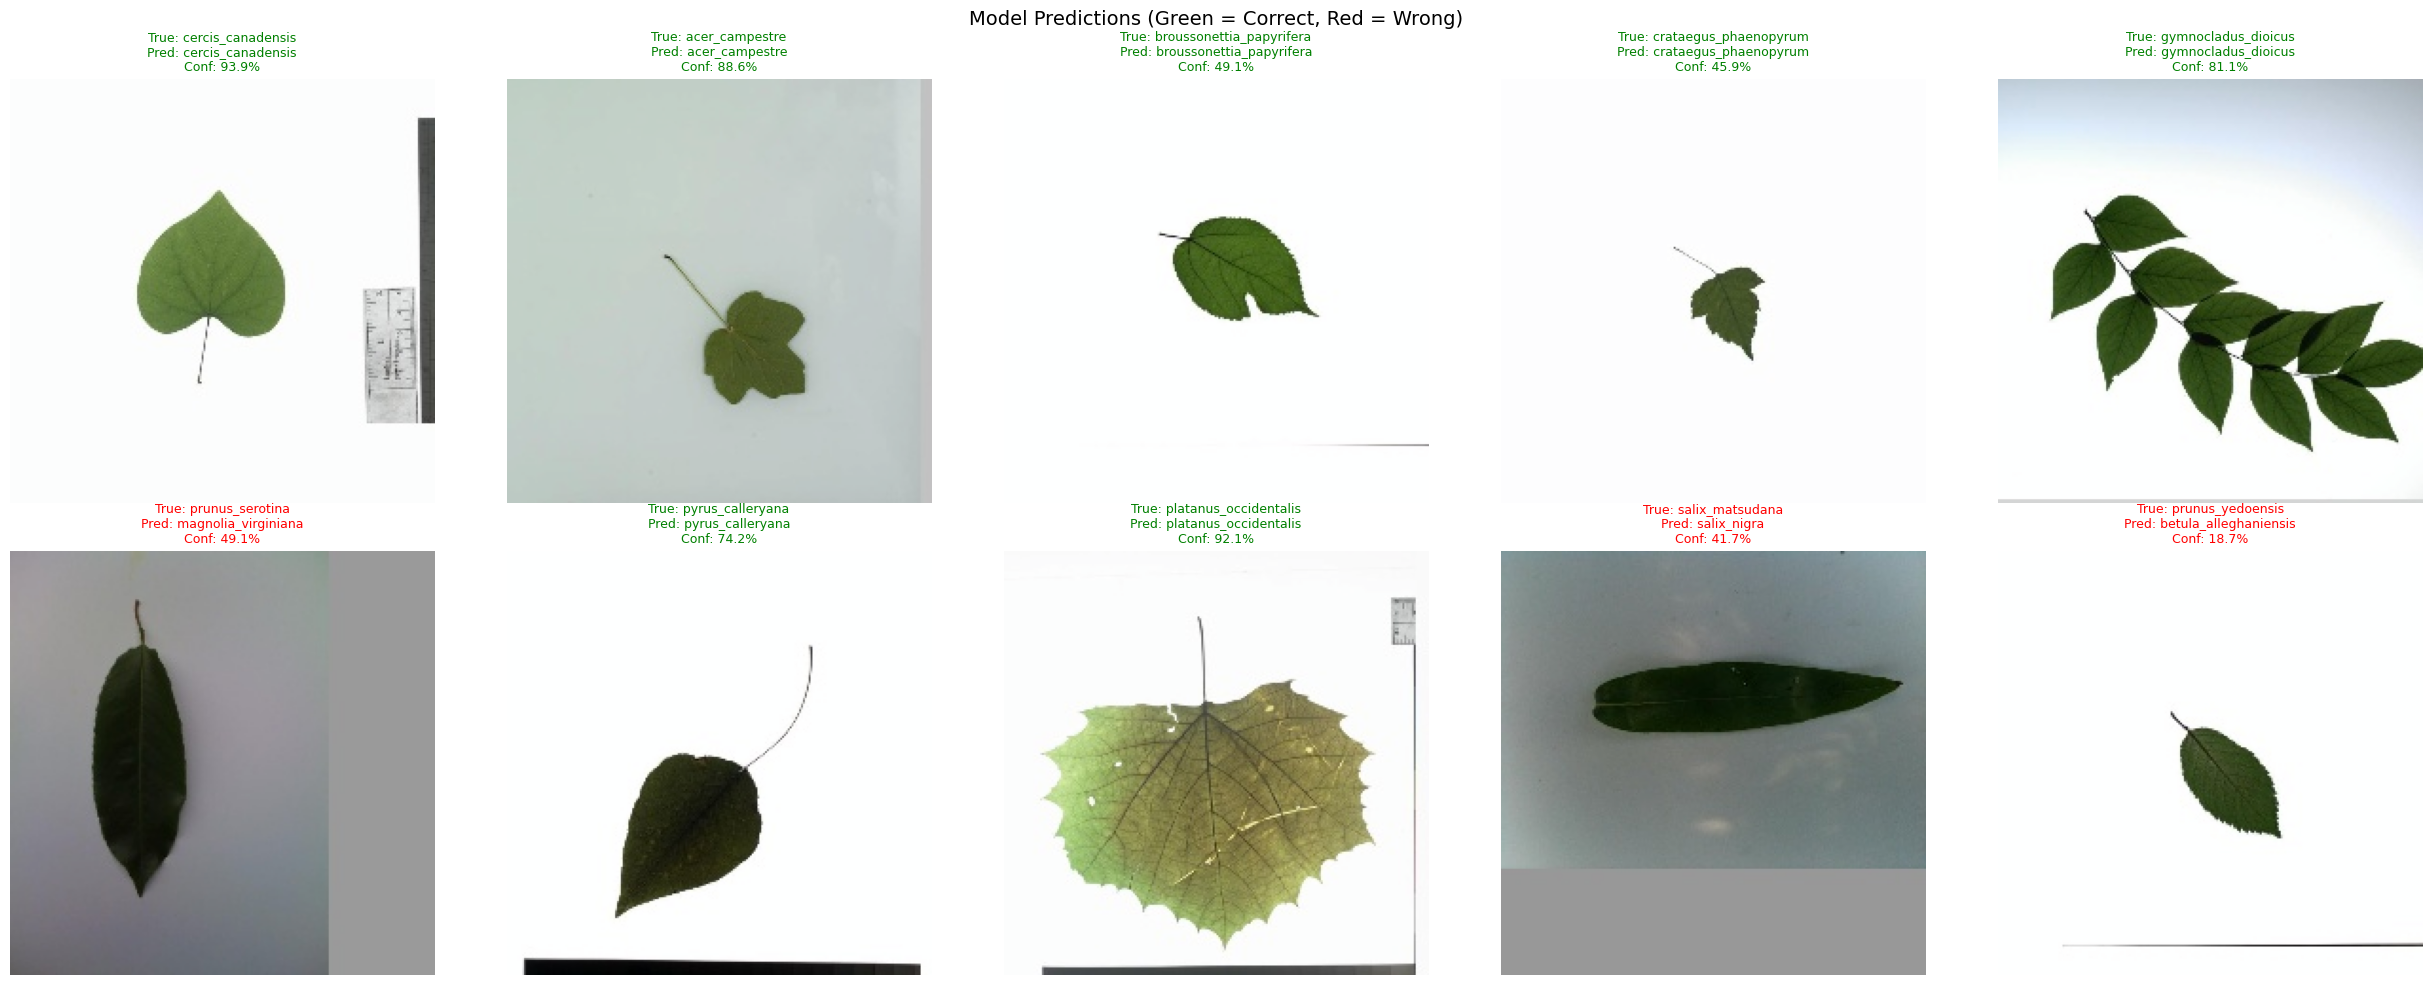

In [46]:
# ============================================
# Testing: Visualize Predictions
# ============================================

# Load the best model
model_v2.load_state_dict(torch.load('best_model_v2.pth'))
model_v2.eval()

# Reverse mapping: number → species name
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

# Pick 10 random images from validation set
sample_indices = torch.randint(0, len(val_dataset), (10,))

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    image, true_label = val_dataset[idx.item()]
    
    # Get prediction
    with torch.no_grad():
        output = model_v2(image.unsqueeze(0).to(device))
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_label = probabilities.max(1)
    
    # Display image (undo normalization for viewing)
    img_display = image.permute(1, 2, 0).numpy()
    img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_display = img_display.clip(0, 1)
    
    true_name = idx_to_class[true_label]
    pred_name = idx_to_class[predicted_label.item()]
    conf = confidence.item() * 100
    
    axes[i].imshow(img_display)
    
    # Green title if correct, red if wrong
    color = 'green' if true_name == pred_name else 'red'
    axes[i].set_title(f'True: {true_name}\nPred: {pred_name}\nConf: {conf:.1f}%', 
                       color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Model Predictions (Green = Correct, Red = Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

## 14. Results Summary

| Experiment | Approach | Best Val Accuracy |
|-----------|----------|-------------------|
| 1 | Custom CNN from scratch (30 epochs) | 61.21% |
| 2 | Transfer Learning + Fine-tuning | 89.75% |
| 2b | Enhanced head + AdamW (too aggressive) | 80.04% |
| 3 | Differential LR Fine-tuning | [UPDATE]% |

### Key Takeaways

1. **Transfer learning dramatically outperforms training from scratch** -- ResNet-50 pretrained on ImageNet already understands visual features. Our custom CNN spent 30 epochs learning what ResNet already knew.

2. **Fine-tuning requires careful learning rate selection** -- Too high (Experiment 2b) destroys pretrained features. Differential learning rates (Experiment 3) give each layer the appropriate amount of adjustment.

3. **Architecture complexity alone doesn't guarantee better results** -- The simple single-Linear head (Experiment 2) outperformed the Sequential head with dropout (Experiment 2b) because the hyperparameters were better calibrated.

4. **Data augmentation is essential for fine-grained classification** -- With some species having only 18 images, augmentation ensures the model sees enough variation to generalize.

5. **Always validate, never trust training accuracy alone** -- Training accuracy measures memorization; validation accuracy measures understanding.